In [1]:
# ==========================================================
# セル1：ライブラリと共通モジュール fft_common の読み込み・解析設定
# ==========================================================
# 【対象】NR-500形式（1行目が "#BeginHeader" で始まるCSV）
#   もう一方の形式は 01_Futaba1ファイル用_圧力経時変化フーリエ変換.ipynb を使ってください。
#
# ★加工対象CSVには一切書き込まない（読み取り専用）★
# ==========================================================
import os
import sys
import time
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog

# --- 共通モジュール fft_common.py を探して読み込む ---
# ノートブックの実行時カレントディレクトリが一定しないため、
# 想定される場所を順に探す。見つからなければ理由を明示して止める。
_here = os.getcwd()
_cands = [
    _here,
    os.path.join(_here, "コードフォルダ"),
    os.path.dirname(_here),
    os.path.join(os.path.dirname(_here), "コードフォルダ"),
]
for _c in _cands:
    if os.path.isfile(os.path.join(_c, "fft_common.py")):
        if _c not in sys.path:
            sys.path.insert(0, _c)
        break
else:
    raise FileNotFoundError(
        "fft_common.py が見つかりません。\n探した場所:\n  "
        + "\n  ".join(_cands)
        + "\nコードフォルダと同じ場所（またはその親フォルダ）で実行してください。"
    )

import fft_common
from fft_common import (
    VOLT_TO_MPA, amp_spectrum, detect_format, folder_tag, list_csv_by_format,
    metrics, read_any, setup_japanese_font,
)

setup_japanese_font(plt)
warnings.filterwarnings("ignore", category=RuntimeWarning,
                        message="All-NaN slice encountered")

# ==========================================================
# ⚙️ 解析設定（ここを変えると解析方法が変わります）
# ==========================================================
TARGET_FORMAT = "nr500"
CHANNELS = ["V03", "V04"]

# --- ゼロ点合わせ（先頭 N 行の平均を全行から引く）---
ZERO_ADJUST = True      # ★NR-500はゼロから始まらないため必須（既定ON）
ZERO_ROWS = 1000                    # ゼロ点合わせに使う先頭行数

# --- スペクトルの求め方 ---
USE_EVENT_WINDOW = True   # True : 圧力が立ち上がっているイベント区間だけを解析（推奨）
                          # False: 記録全体を解析（＝従来の動作。無信号区間のノイズが混入）
DETREND = True            # FFT前に解析区間の平均を引く（False が従来の動作）
WINDOW = "hann"           # "hann"（漏れが少ない）/ "none"（＝従来の矩形窓）
# ==========================================================
# ※グラフの見た目（周波数軸の範囲・対数軸など）は セル2の先頭 にあります

print("✅ 準備完了")
print(f"   共通モジュール : {fft_common.__file__}")
print(f"   対象形式       : {TARGET_FORMAT}   チャンネル: {', '.join(CHANNELS)}")
if ZERO_ADJUST:
    print(f"   ゼロ点合わせ   : ON（先頭 {ZERO_ROWS} 行の平均を全行から引く）")
else:
    print("   ゼロ点合わせ   : OFF")
print(f"   解析区間       : {'イベント区間のみ' if USE_EVENT_WINDOW else '記録全体（従来動作）'}")
print(f"   窓関数         : {WINDOW} / 直流除去: {DETREND}")
print("👉 次のセルを実行してください。")

✅ 準備完了
   共通モジュール : c:\Users\0uh2j\Desktop\vscodeで\フーリエ変換\コードフォルダ\fft_common.py
   対象形式       : nr500   チャンネル: V03, V04
   ゼロ点合わせ   : ON（先頭 1000 行の平均を全行から引く）
   解析区間       : イベント区間のみ
   窓関数         : hann / 直流除去: True
👉 次のセルを実行してください。


✅ 読み込み完了: 040_210℃_080_1.0mm.csv
   データ点数    : 1,000,000 点
   サンプリング周期: 5 µs  (200 kHz)
   計測時間      : 5.0000 秒
   Nyquist周波数 : 100,000 Hz
   ゼロ点合わせ  : 先頭1000行の平均を減算（V03=-0.1756, V04=-1.1230 MPa）

   [V03]
     ピーク        : 27.756 MPa （基準線から 27.680 MPa）
     イベント区間  : 2.097 〜 2.560 秒（解析範囲 1.981〜2.676 秒 / 138,901点）
     立上り(10-90%): 92.0 ms → 必要帯域 約 3.8 Hz
     f99 / f99.9   : 10.08 Hz / 17.28 Hz
     ノイズRMS     : 0.0593 MPa（SNR 187）
     品質フラグ    : ok
   [V04]
     ピーク        : 22.163 MPa （基準線から 22.120 MPa）
     イベント区間  : 2.115 〜 2.567 秒（解析範囲 2.003〜2.680 秒 / 135,451点）
     立上り(10-90%): 80.0 ms → 必要帯域 約 4.4 Hz
     f99 / f99.9   : 10.34 Hz / 19.20 Hz
     ノイズRMS     : 0.0593 MPa（SNR 186）
     品質フラグ    : ok


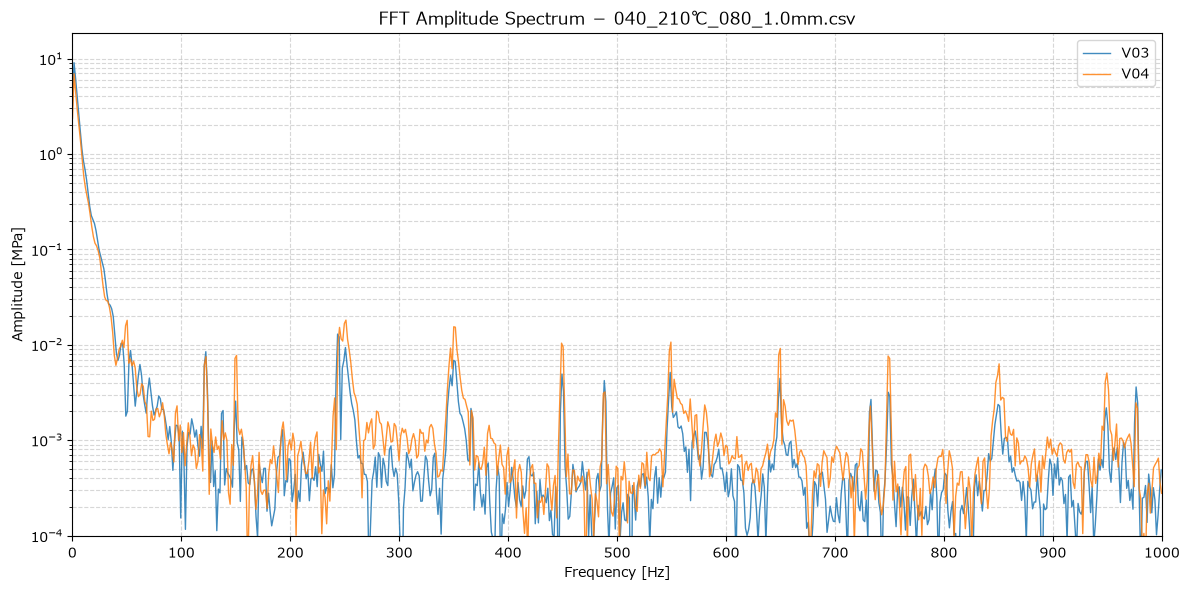


💡 カットオフ周波数を全ファイル横断で決めたい場合は
   07_カットオフ周波数決定_全ファイル横断.ipynb を使ってください。


In [4]:
# ==========================================================
# セル2：ファイルを1つ選んでFFTし、グラフと指標を表示する
# ==========================================================
# ---- グラフの見た目 ----
LOG_Y = True                       # Y軸を対数にする（False が従来のリニア軸）
X_MIN, X_MAX, X_STEP = 0, 1000, 100  # 周波数軸の範囲と目盛り間隔 [Hz]
Y_MIN, Y_MAX = 1e-4, None          # 対数軸のときの下限／上限（None で自動）
# ------------------------

root = tk.Tk()
root.withdraw()
root.attributes("-topmost", True)
file_path = filedialog.askopenfilename(
    title="解析するNR-500形式のCSVファイルを選択してください",
    filetypes=[("CSVファイル", "*.csv"), ("すべてのファイル", "*.*")],
)
root.destroy()

fmt = detect_format(file_path) if file_path else None

if not file_path:
    print("⚠️ ファイル選択がキャンセルされました。処理を終了します。")

elif fmt != TARGET_FORMAT:
    # 形式違いを黙って落とさず、はっきり知らせる
    print(f"⚠️ このファイルは NR-500形式 ではありません（判定: {fmt or '不明な形式'}）")
    print(f"   選択されたファイル: {os.path.basename(file_path)}")
    with open(file_path, "r", encoding="cp932", errors="replace") as f:
        print(f"   1行目: {f.readline().rstrip()}")
    print(f"\n   → {'01_Futaba1ファイル用_圧力経時変化フーリエ変換.ipynb' if fmt else '対象外のファイルです'} を使ってください。")

else:
    df, dt, info = read_any(file_path, channels=CHANNELS,
                            zero=ZERO_ADJUST, zero_rows=ZERO_ROWS)
    print(f"✅ 読み込み完了: {os.path.basename(file_path)}")
    print(f"   データ点数    : {len(df):,} 点")
    print(f"   サンプリング周期: {dt * 1e6:.4g} µs  ({1 / dt / 1000:.3g} kHz)")
    print(f"   計測時間      : {len(df) * dt:.4f} 秒")
    print(f"   Nyquist周波数 : {1 / (2 * dt):,.0f} Hz")
    if info["zero_applied"]:
        off = ", ".join(f"{k}={v:+.4f}" for k, v in info["zero_offset"].items())
        print(f"   ゼロ点合わせ  : 先頭{ZERO_ROWS}行の平均を減算（{off} MPa）")
    print()

    fig, ax = plt.subplots(figsize=(12, 6))
    for ch in CHANNELS:
        y = df[ch].to_numpy(dtype=np.float64)
        m, _spec, (i0, i1) = metrics(
            y, dt, use_event=USE_EVENT_WINDOW, detrend=DETREND, window=WINDOW,
            zero_rows=ZERO_ROWS if info["zero_applied"] else None)
        # グラフは振幅スペクトル [MPa]（従来と同じ縦軸の意味）
        f, a = amp_spectrum(y[i0:i1 + 1], dt, detrend=DETREND, window=WINDOW)
        sel = (f >= X_MIN) & (f <= X_MAX)      # ★描画前に帯域を切る（点数を減らす）
        ax.plot(f[sel], a[sel], label=ch, alpha=0.85, linewidth=1.0)

        print(f"   [{ch}]")
        print(f"     ピーク        : {m['peak_MPa']:.3f} MPa "
              f"（基準線から {m['peak_minus_baseline_MPa']:.3f} MPa）")
        print(f"     イベント区間  : {m['event_start_s']:.3f} 〜 {m['event_end_s']:.3f} 秒"
              f"（解析範囲 {m['analysis_start_s']:.3f}〜{m['analysis_end_s']:.3f} 秒 / "
              f"{m['analysis_points']:,}点）")
        print(f"     立上り(10-90%): {m['rise_time_ms']:.1f} ms "
              f"→ 必要帯域 約 {m['required_bw_Hz']:.1f} Hz")
        print(f"     f99 / f99.9   : {m['f99_Hz']:.2f} Hz / {m['f999_Hz']:.2f} Hz")
        print(f"     ノイズRMS     : {m['noise_rms_MPa']:.4f} MPa（SNR {m['snr']:.0f}）")
        print(f"     品質フラグ    : {m['flags']}")

    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("Amplitude [MPa]")
    ax.set_title(f"FFT Amplitude Spectrum － {os.path.basename(file_path)}")
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_xticks(np.arange(X_MIN, X_MAX + X_STEP, X_STEP))
    if LOG_Y:
        ax.set_yscale("log")
        ax.set_ylim(Y_MIN, Y_MAX)
    ax.legend()
    ax.grid(True, which="both", linestyle="--", alpha=0.5)
    fig.tight_layout()
    plt.show()

    print("\n💡 カットオフ周波数を全ファイル横断で決めたい場合は")
    print("   07_カットオフ周波数決定_全ファイル横断.ipynb を使ってください。")